<a href="https://colab.research.google.com/github/Priyanshi07-ai/iot_device_grouping_based_on_usage/blob/main/unsupervised.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**PROJECT NAME - IoT Device Grouping**

**CONTRIBUTION - INDIVIDUAL NAME - PRIYANSHI BHANDARI**

github = https://github.com/Priyanshi07-ai

**Grouping IoT Devices with Unsupervised Learning**

Among the tasks here, one involved studying power habits of household gadgets connected online. Instead of relying on fixed categories, the approach looked for common rhythms across appliances such as heaters, cooling boxes, washing units, and work-from-home gear. Information came in streams - energy readings tagged by time, tied together with air warmth, room pressure, dampness levels. Patterns emerged when actions shared likeness, even if never labeled beforehand. Sorting happened through resemblance, guided purely by how each device drew current over hours.
First up, cleaning the data meant tossing out bits that didn’t help - timestamps, random texts, stuff like that. Missing numbers got filled or adjusted so nothing was left hanging. Then came scaling, making sure each feature played fair without one overpowering another. Into exploration next, just poking around to spot odd points and get a feel for what linked to what. Shapes of distributions showed up, patterns emerged, relationships quietly revealed themselves.
Simplifying the data meant using Principal Component Analysis to cut down noise. Important patterns stayed clear even as feature count dropped. Clustering followed, handled by the K-Means method. Figuring out cluster numbers started with the Elbow Method - then double-checked through Silhouette Scores. Two groups stood out most clearly. After PCA, that split reached a silhouette value near 0.45.
Starting off differently, I gave hierarchical clustering a shot along with t-SNE visuals so the cluster shapes would show up clearer. Not sticking to one method, I played around with GridSearchCV for adjustments; however, gains stayed small since its main aim is lowering inertia instead of sharpening cluster separation.
When it comes to power habits, gadgets connected online fall into separate clusters. Some sip electricity slowly; others gulp it down fast - these behaviors form clear lines between them. Spotting these patterns helps cut waste, flag odd actions, or make homes smarter behind the scenes. Not every device runs the same way, after all.
Looking back, working through this made it clear just how much you can learn from raw data without any labels at all. Principal Component Analysis pulled out patterns I wouldn’t have spotted by eye. Clustering with K-Means sorted things into groups that actually made sense. Without telling the model what to look for, it still found structure hiding underneath. Each step showed a different way to explore information blindly. Turns out, unlabeled data isn’t useless - it just needs the right tools. These techniques opened up another path to see what’s really inside a dataset.

#**DATASET**

In [22]:
import pandas as pd
import numpy as np

# Load dataset
data = pd.read_csv("HomeC.csv",  nrows=35000)
print(data.head(2))

selected_columns = [
    'House overall [kW]',
    'Furnace 1 [kW]',
    'Furnace 2 [kW]',
    'Home office [kW]',
    'Fridge [kW]',
    'Dishwasher [kW]',
]

data = data[selected_columns]
print(data.info())
# Handle missing values
data = data.fillna(data.mean())

# Remove duplicates
data = data.drop_duplicates()

from scipy import stats
import numpy as np

z = np.abs(stats.zscore(data))
data = data[(z < 3).all(axis=1)]

         time  use [kW]  gen [kW]  House overall [kW]  Dishwasher [kW]  \
0  1451624400  0.932833  0.003483            0.932833         0.000033   
1  1451624401  0.934333  0.003467            0.934333         0.000000   

   Furnace 1 [kW]  Furnace 2 [kW]  Home office [kW]  Fridge [kW]  \
0        0.020700        0.061917          0.442633      0.12415   
1        0.020717        0.063817          0.444067      0.12400   

   Wine cellar [kW]  ...  visibility  summary  apparentTemperature  pressure  \
0          0.006983  ...        10.0    Clear                29.26   1016.91   
1          0.006983  ...        10.0    Clear                29.26   1016.91   

   windSpeed  cloudCover  windBearing  precipIntensity  dewPoint  \
0       9.18  cloudCover        282.0              0.0      24.4   
1       9.18  cloudCover        282.0              0.0      24.4   

   precipProbability  
0                0.0  
1                0.0  

[2 rows x 32 columns]
<class 'pandas.core.frame.DataFram

/tmp/ipykernel_7202/1646005942.py:5: DtypeWarning: Columns (27) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv("HomeC.csv",  nrows=35000)


# ***standardization***

In [23]:
from sklearn.preprocessing import StandardScaler

scaled_data = StandardScaler().fit_transform(data)

# ***EDA***

In [24]:
print(data.describe())

       House overall [kW]  Furnace 1 [kW]  Furnace 2 [kW]  Home office [kW]  \
count        22296.000000    22296.000000    22296.000000      22296.000000   
mean             0.956486        0.214590        0.230860          0.088084   
std              0.514877        0.207272        0.247678          0.088601   
min              0.000467        0.019267        0.059450          0.039233   
25%              0.554996        0.021350        0.064367          0.042200   
50%              0.886675        0.089750        0.067717          0.048767   
75%              1.282200        0.478950        0.511758          0.094867   
max              3.070850        0.857683        0.775417          0.465400   

        Fridge [kW]  Dishwasher [kW]  
count  22296.000000     22296.000000  
mean       0.053261         0.004123  
std        0.058667         0.024604  
min        0.004083         0.000000  
25%        0.005017         0.000017  
50%        0.005350         0.000067  
75%        0.12

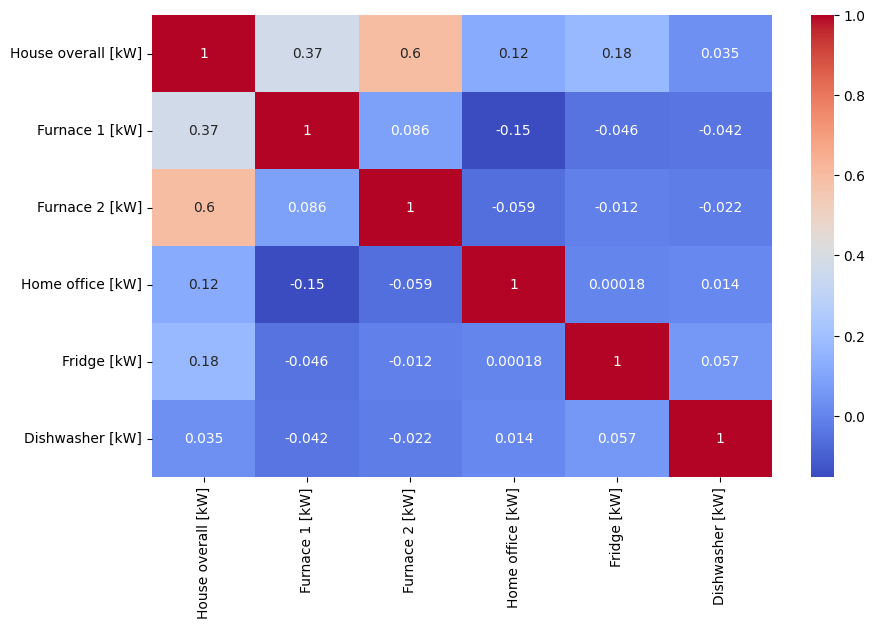

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.heatmap(data.corr(), annot=True, cmap="coolwarm")
plt.show()

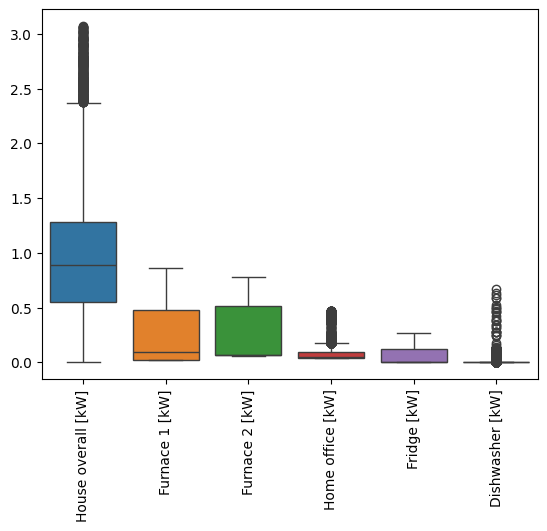

In [26]:
sns.boxplot(data=data)
plt.xticks(rotation=90)
plt.show()

In [27]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_data)

#**Clustering**

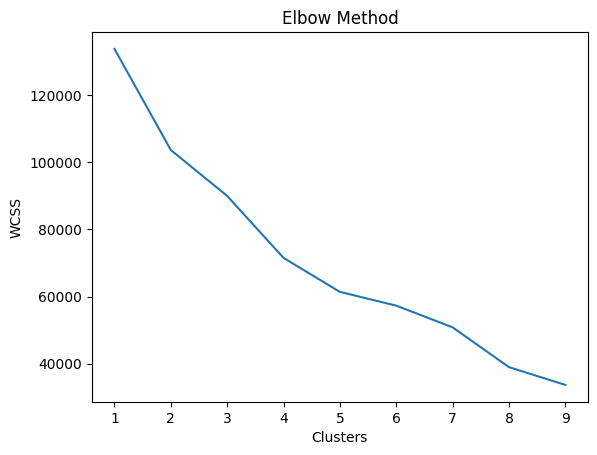

In [28]:
from sklearn.cluster import KMeans

wcss = []
for i in range(1, 10):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,10), wcss)
plt.xlabel("Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [29]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

for k in range(2,6):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(scaled_data)
    score = silhouette_score(scaled_data, labels)
    print(k, score)

2 0.2998822790746646
3 0.26564743559489046
4 0.3161219557759743
5 0.3357371315600469


In [30]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

for k in range(2,6):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(pca_data)
    score = silhouette_score(pca_data, labels)
    print(k, score)

2 0.4193959068163665
3 0.3601720859290461
4 0.3747323048833408
5 0.4369544004126692


**k - means**

In [31]:
kmeans = KMeans(n_clusters=3)
clusters = kmeans.fit_predict(scaled_data)

**Hierarchical Clustering**

In [32]:
from sklearn.cluster import AgglomerativeClustering

hc = AgglomerativeClustering(n_clusters=3)
hc_clusters = hc.fit_predict(scaled_data)

**t-SNE**

In [33]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42)
tsne_data = tsne.fit_transform(scaled_data)

**Silhoutte Score**

# **Model Tuning**

**GridSearchCV**

In [34]:
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ('kmeans', KMeans(random_state=42))
])

param_grid = {
    'kmeans__n_clusters': [2,3,4,5],
    'kmeans__max_iter': [100,200,300],
    'kmeans__init': ['k-means++','random']
}

grid = GridSearchCV(pipeline, param_grid)
grid.fit(scaled_data)

best_model = grid.best_estimator_
print(grid.best_params_)

{'kmeans__init': 'random', 'kmeans__max_iter': 100, 'kmeans__n_clusters': 5}


**PCA Component Tuning**

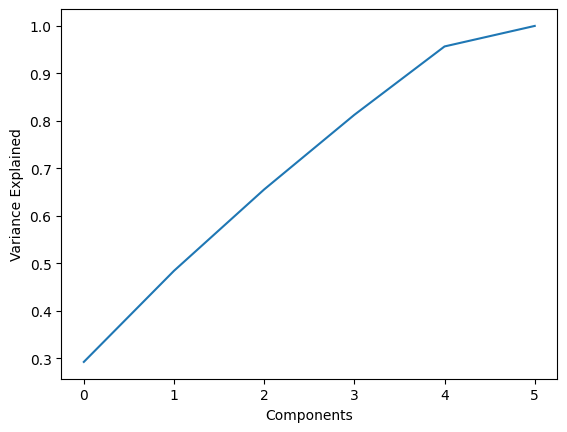

In [35]:
pca = PCA().fit(scaled_data)
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel("Components")
plt.ylabel("Variance Explained")
plt.show()

**Re-run Clustering**

In [36]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters = 5, max_iter = 100, init = 'random')

final_clusters = kmeans.fit_predict(scaled_data)

data['final_cluster'] = final_clusters

In [37]:
# kmeans = KMeans(n_clusters=3, random_state=42)
# final_clusters = kmeans.fit_predict(pca_data)

# data['final_cluster'] = final_clusters

#**Visualization**

**PCA Cluster Plot**

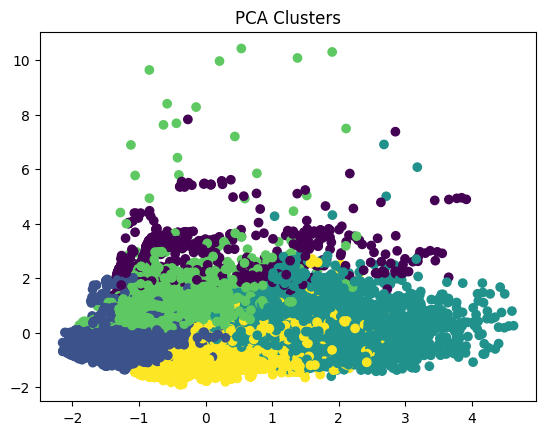

In [38]:
plt.scatter(pca_data[:,0], pca_data[:,1], c=data['final_cluster'])
plt.title("PCA Clusters")
plt.show()

**Cluster Centroids**

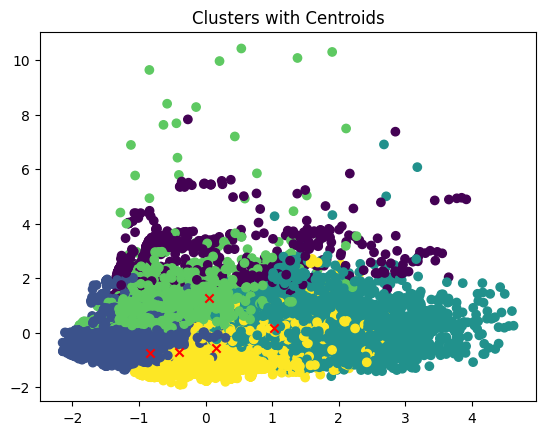

In [39]:
centroids = kmeans.cluster_centers_

plt.scatter(pca_data[:,0], pca_data[:,1], c=data['final_cluster'])
plt.scatter(centroids[:,0], centroids[:,1], c='red', marker='x')
plt.title("Clusters with Centroids")
plt.show()

**Dendrogram**

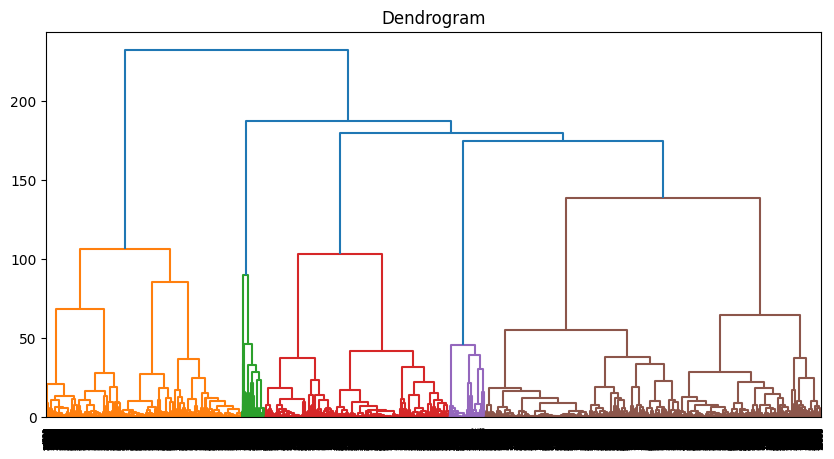

In [40]:
from scipy.cluster.hierarchy import dendrogram, linkage

linked = linkage(scaled_data, method='ward')

plt.figure(figsize=(10,5))
dendrogram(linked)
plt.title("Dendrogram")
plt.show()

**t-SNE Plot**

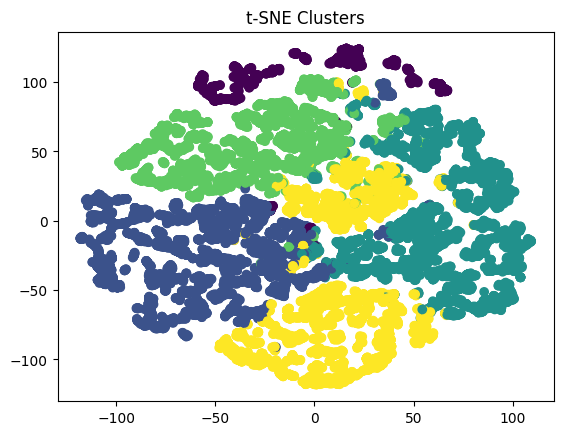

In [41]:
plt.scatter(tsne_data[:,0], tsne_data[:,1], c=data['final_cluster'])
plt.title("t-SNE Clusters")
plt.show()

In [42]:
from sklearn.metrics import silhouette_score

score = silhouette_score(scaled_data, data['final_cluster'])
print("Silhouette Score:", score)

Silhouette Score: 0.3588185019421778
